### Conceptual

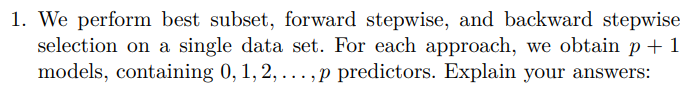

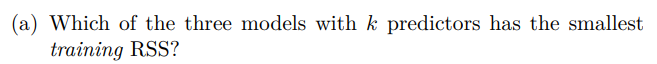

First of all, with increasing number of predictors - training MSE decreases and R2 increases. This is a natural process, as model has more info to study from, and getting more flexible, harder to interpret.

If we are talking which of three models has the smallest trainig RSS - i would say that model performed with predictors chosen by `best subset selection`, because this approach goes along all possible combinations, and can change the list of predictors every time, while stepwise approaches have no guarantee that they choose best model.

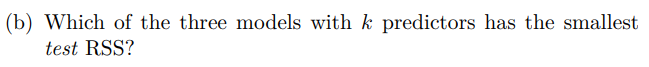

To be honest, there is no guarantee that some model has smaller test RSS than other. It can happened that best subset approch chose some variables that performed better in traning, but in test - the results are poor. 

For example, we have 11 predictors, for every of those approaches - the smallest train RSS will be if include all 11 predictors, because its natural. But, the main moment is - bias-variance trade-off. We need to choose those number of predictors, that has the smallest test MSE. Maybe the bias will be higher, but the variance will be smaller as we choose simplier model.

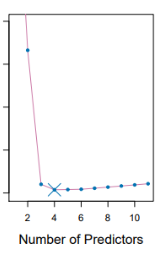

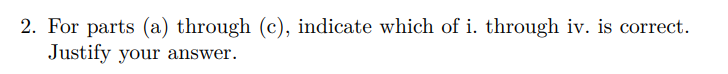

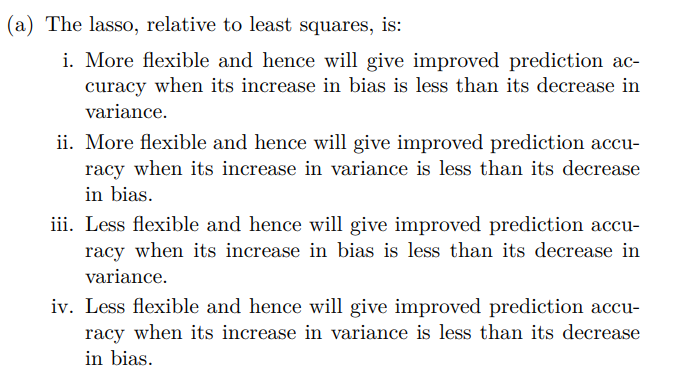

iii. statement is the one correct here. Why?

First of all, its important to unrderstand, that `lasso is less flexible than least squares`. The idea of lasso - get simple model, with a few non-zero predictors. We penalize model(with l1 penalty) to make it simplier, and with increase of penalty(lambda) - the variance is decreaing, while the bias - slightly increasing --> bias-variance trade-off.

In case, when lambda = 0 --> we get leasr squares, but with increasig of lambda --> lasso is getting less flexible

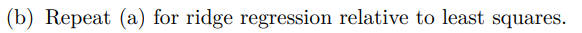

Here also iii. statemnt is true. The goal of ridge regression is to shrink coefficients, that approaches zero, but will never be zero, since ridge regression does not perform subset selection(as lasso). So, model will be inflexible, and with slightly increase of bias we get decrease in variance.

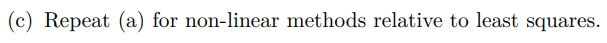

Statement (i) incorrectly claims that a more flexible method results in an increase in bias and a decrease in variance. The correct relationship is that a more flexible method decreases bias and increases variance, and improved accuracy results when the latter is smaller than the former(ii).

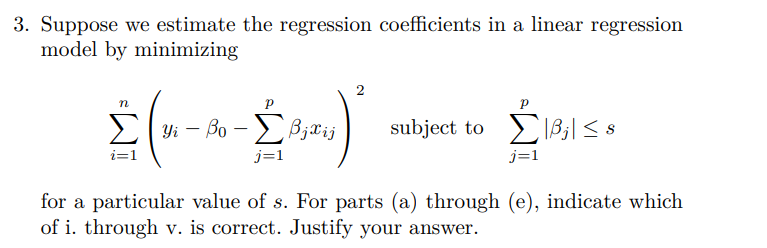

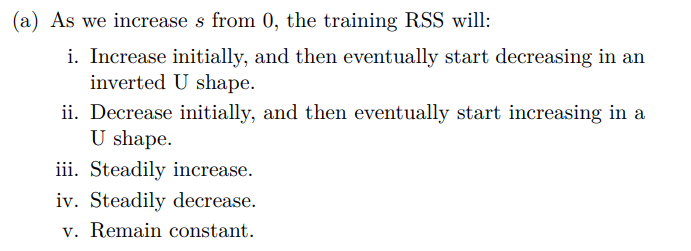

First of all, we can think of $$\sum_{j=1}^{p} |\beta_j| \leq s$$ as a budget, that we give model to spend. In case of lasso - it selects only some coefficents, making other equal zero. Making this budget small - leads to bigger amount of null coefficients.

And as we know: with increasing of predictors in a model - training RSS is naturally deceasing

So, my answer: iiii. Steadily decrease

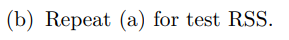

In case of test RSS - naturally we have U-shape.

With increasing of flexibility(s) we allow model to have bigger value of a coeffiecint or simply more cofficients. The test RSS decrease, but in some moment - it starts to increasinf, as the model flexibility will affect high variance.

My answer is: ii.

As i said above: the increasing of space of possible values of B - allows model to take bigger value of coefficients and bigger number of them. This will lead to increasig of variance.

My answer: iii.

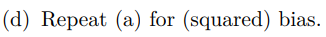

This is also obvious, that when we increasing the flexibility of the model - we allow it to follow more difficult patterns, and as a consequence - the bias is decreasing, the results are more accurate.

My asnwer: iv.

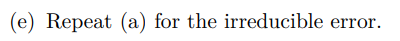

The irreducible error stays always the same, because it some noise with whom our data was created - we cannot reduce it.

My answer: v.

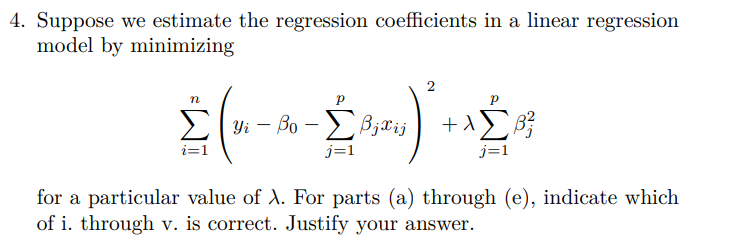

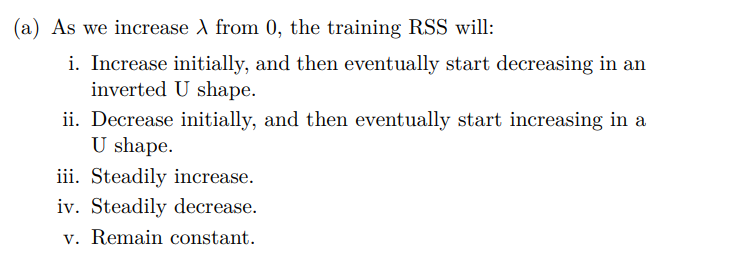

First of all, here we have a loss function for Ridge regression, where λ - is a tuning hyperparameter, which measure, how big penalty have to be. 
- with increaing of λ - we have stricter penalty, and as a consequence - less flexible model, with shrinked coeficients towards 0.
- with decreaing of λ - we allow model to have bigger values of coefficients - model is more flexible
- when λ = 0 - we have leasr squares

In case of traning RSS, with increasing of λ - model is getting simplier, so traning RSS is getting less accurate - it increases.

So, my answer is: iii.

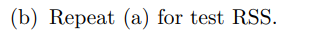

For test RSS we have U-shape, because:
- we start with least squaers(λ = 0) which can have high variance
- than, the test RSS is decreasig with increasing λ
- but in some moment, it start to increasing becaiuse the model is getting very simple

So, my answer is: ii.

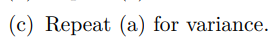

Variance is steadily decreases, as the penalty getting more valuable, making it have small coeeficients, and as a consequence - simplier model

Answer: iv.

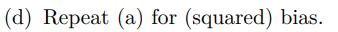

As our model is getting less flexible, it can not follow some difficult patterns, and as a result - the bias will be slightly increases.

My answer is: iii.

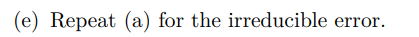

It will be the same.
Answer: v.

### Applied

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import seaborn as sns
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
(Stepwise,
sklearn_selected,
sklearn_selection_path)

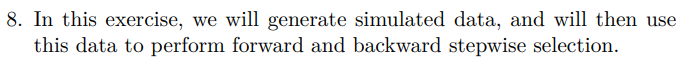

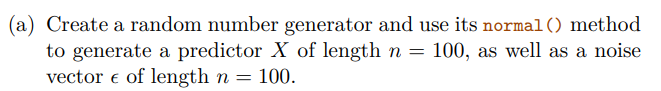

In [7]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
eps = rng.normal(size=100)

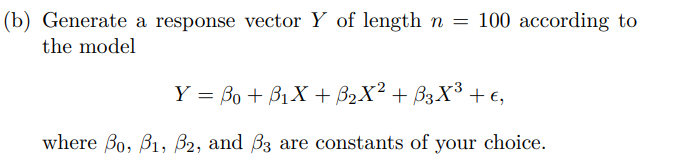

In [8]:
b0 = 50
b1 = 44
b2 = 97
b3 = 5

y = b0 + b1 * x + b2 * x**2 + b3 * x**3 + eps
y[:10]

array([ 76.34534441, 155.26730418,  75.18533933, 146.99222541,
       174.27288033,  89.79538712,  52.69118937, 107.79282114,
        80.92941577,  71.34962123])

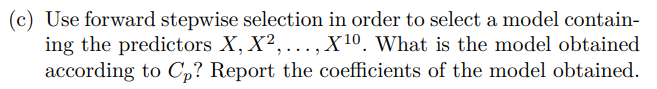

In [9]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic"
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n 

In order to use $C_p$ we need to compute variance

In [10]:
df = pd.DataFrame({f"X_{i}": x**i for i in range(1, 11)})
df["y"] = y

df

,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,y
0,0.345584,0.119428,0.041273,0.014263,4.929119e-03,1.703426e-03,5.886770e-04,2.034375e-04,7.030477e-05,2.429622e-05,76.345344
1,0.821618,0.675056,0.554639,0.455701,3.744123e-01,3.076239e-01,2.527494e-01,2.076635e-01,1.706201e-01,1.401846e-01,155.267304
2,0.330437,0.109189,0.036080,0.011922,3.939525e-03,1.301765e-03,4.301515e-04,1.421380e-04,4.696766e-05,1.551986e-05,75.185339
3,-1.303157,1.698219,-2.213046,2.883947,-3.758236e+00,4.897573e+00,-6.382308e+00,8.317150e+00,-1.083855e+01,1.412434e+01,146.992225
4,0.905356,0.819669,0.742092,0.671858,6.082703e-01,5.507011e-01,4.985804e-01,4.513927e-01,4.086711e-01,3.699927e-01,174.272880
...,...,...,...,...,...,...,...,...,...,...,...
95,-2.250854,5.066345,-11.403604,25.667851,-5.777459e+01,1.300422e+02,-2.927060e+02,6.588386e+02,-1.482950e+03,3.337904e+03,383.762385
96,-0.138655,0.019225,-0.002666,0.000370,-5.124869e-05,7.105904e-06,-9.852714e-07,1.366131e-07,-1.894214e-08,2.626428e-09,46.860329
97,0.033000,0.001089,0.000036,0.000001,3.913601e-08,1.291492e-09,4.261938e-11,1.406444e-12,4.641280e-14,1.531627e-15,51.725924
98,-1.425349,2.031620,-2.895767,4.127478,-5.883097e+00,8.385466e+00,-1.195222e+01,1.703608e+01,-2.428236e+01,3.461083e+01,170.421323


In [11]:
design = MS(df.columns.drop("y")).fit(df)
Y = np.array(df["y"])
X = design.transform(df).drop("intercept", axis=1)

sigma2 = OLS(Y, X).fit().scale
sigma2

np.float64(814.8803706928061)

In [12]:
neg_Cp = partial(nCp, sigma2)

In [13]:
strategy = Stepwise.first_peak(design,
                               direction="forward",
                               max_terms=len(design.terms))

model_forward = sklearn_selected(OLS, strategy, scoring=neg_Cp)

model_forward.fit(X, Y)
model_forward.selected_state_

('X_1', 'X_2', 'X_3')

In [14]:
model_forward.results_.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.597e+05
Date:                Fri, 17 Oct 2025   Prob (F-statistic):          2.85e-194
Time:                        23:17:30   Log-Likelihood:                -140.47
No. Observations:                 100   AIC:                             288.9
Df Residuals:                      96   BIC:                             299.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     49.9428      0.120    416.437      0.000      49.705      50.181
X_1           44.1146      0.187    235.313      0.000      43.742      44.487
X_2           96.9529      0.099    979.102      0.000      96.756      97.149
X_3            4.9357      0.060     82.151      0.000       4.816       5.055
==============================================================================
Omnibus:                        0.845   Durbin-Watson:                   2.199
Prob(Omnibus):                  0.655   Jarque-Bera (JB):                0.392
Skew:                           0.052   Prob(JB):                        0.822
Kurtosis:                       3.289   Cond. No.                         5.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Model is fitted very well and coefficients are pretty close to true

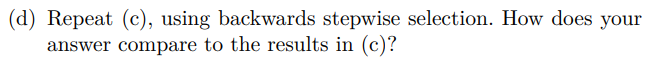

In [15]:
strategy = Stepwise.first_peak(design,
                               direction="backwards",
                               max_terms=len(design.terms))

model_backward = sklearn_selected(OLS, strategy, scoring=neg_Cp)
model_backward.fit(X, Y)

model_backward.selected_state_

('X_1', 'X_2', 'X_3')

In [16]:
model_backward.results_.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.597e+05
Date:                Fri, 17 Oct 2025   Prob (F-statistic):          2.85e-194
Time:                        23:17:30   Log-Likelihood:                -140.47
No. Observations:                 100   AIC:                             288.9
Df Residuals:                      96   BIC:                             299.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     49.9428      0.120    416.437      0.000      49.705      50.181
X_1           44.1146      0.187    235.313      0.000      43.742      44.487
X_2           96.9529      0.099    979.102      0.000      96.756      97.149
X_3            4.9357      0.060     82.151      0.000       4.816       5.055
==============================================================================
Omnibus:                        0.845   Durbin-Watson:                   2.199
Prob(Omnibus):                  0.655   Jarque-Bera (JB):                0.392
Skew:                           0.052   Prob(JB):                        0.822
Kurtosis:                       3.289   Cond. No.                         5.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The results are the same as in forward selection approach.

SO, what conclusion we can make?

Our reponse was generated by X, some coefficients and noise.
Model that was fitted had 10 predictors, 3 from them are those that created a response.

Forward approach started from null model and everytime added new predictor to mimize $C_p$, and after it added $X_4$, it saw that model with 3 first predictors were best than those with 4 - and it selects those 3 true preditors, and coefficients to them are pretty close to true

The same stuff with backward selection approach.

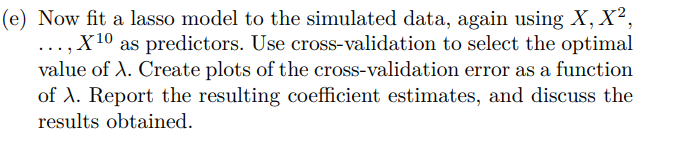

In [17]:
scaler = StandardScaler()

outer_valid = skm.ShuffleSplit(n_splits=1,
                               random_state=1,
                               test_size=0.25)

inner_kfold = skm.KFold(n_splits=5,
                        random_state=2,
                        shuffle=True)

lassoCV = skl.ElasticNetCV(l1_ratio=1, cv=inner_kfold)


pipeCV = Pipeline(steps=[
  ("scaler", scaler),
  ("lasso", lassoCV)
])

results = skm.cross_validate(estimator=pipeCV,
                             cv=outer_valid,
                             X=X,
                             y=Y,
                             scoring="neg_mean_squared_error")
-results["test_score"]

array([0.95807935])

In [18]:
pipeCV.fit(X, Y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 ElasticNetCV(cv=KFold(n_splits=5, random_state=2, shuffle=True),
                              l1_ratio=1))])

In [19]:
tuned_lasso = pipeCV.named_steps["lasso"]
tuned_lasso.coef_

array([ 3.73534163e+01,  1.14483615e+02,  1.43824335e+01,  0.00000000e+00,
        0.00000000e+00,  2.05614973e-01, -0.00000000e+00,  8.29412867e-02,
       -0.00000000e+00,  5.53145176e-02])

In [20]:
tuned_lasso.alpha_

np.float64(0.09434150271628824)

Text(0, 0.5, 'Cross-validated MSE')

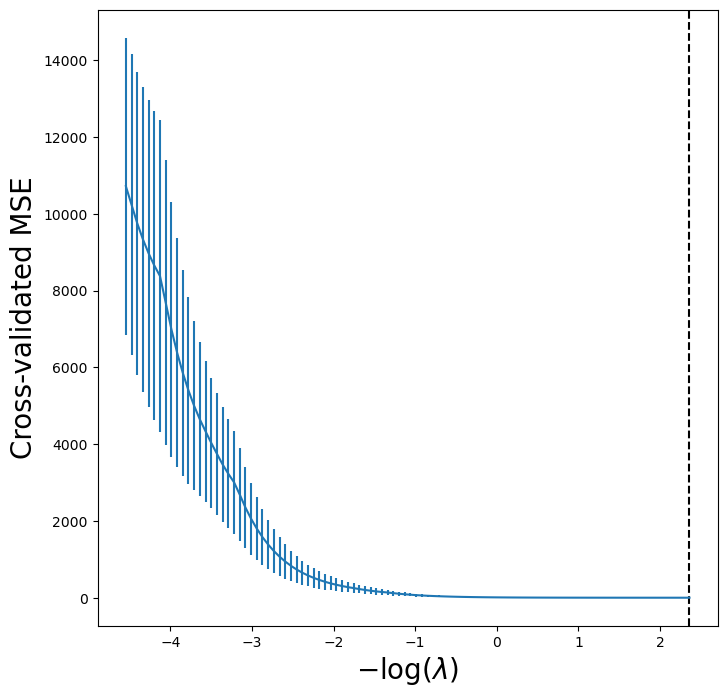

In [21]:
K = 5

lasso_fig, ax = subplots(figsize=(8, 8))
ax.errorbar(
  -np.log(tuned_lasso.alphas_),
  tuned_lasso.mse_path_.mean(1),
  yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K)
)
ax.axvline(-np.log(tuned_lasso.alpha_), c="k", ls="--")
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20)

So, we see that lasso chose a very small lambda, and as a consequence - small penalty.

In [22]:
scaler = pipeCV.named_steps["scaler"]
scaler.scale_

array([8.51556733e-01, 1.18465105e+00, 2.89023195e+00, 6.57522087e+00,
       1.69184027e+01, 4.29300022e+01, 1.13969174e+02, 3.00430010e+02,
       8.08303627e+02, 2.16420574e+03])

In [23]:
tuned_lasso.coef_ / scaler.scale_

array([ 4.38648593e+01,  9.66391029e+01,  4.97622121e+00,  0.00000000e+00,
        0.00000000e+00,  4.78954023e-03, -0.00000000e+00,  2.76075239e-04,
       -0.00000000e+00,  2.55588074e-05])

In [24]:
tuned_lasso.intercept_ - np.dot(tuned_lasso.coef_, scaler.mean_ /scaler.scale_)

np.float64(50.109058104632226)

$$\hat{\beta}_0=50.1\quad\hat{\beta}_1=43.86\quad\hat{\beta}_2=96.64\quad\hat{\beta}_3=4.98\quad\hat{\beta}_4=0.00\quad$$
$$\hat{\beta}_5=0.00\quad\hat{\beta}_6=0.0048\quad\hat{\beta}_7=0.00\hat{\beta}_8=0.0003\quad\hat{\beta}_9=0.00\quad\hat{\beta}_{10}=0.00003$$

And what we can see? First of all, lest reminf that Lasoo uses model selection, making some coefficients equals zero, and we can see, that those tree predictors, that created data, are very close to true, and other - equals or approaches zero

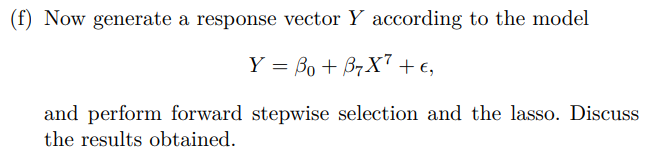

In [25]:
rng = np.random.default_rng(1)
x = rng.normal(size=n)
eps = rng.normal(size=n)

NameError: name 'n' is not defined

$$Y = β_0 + β_7X_7 + err$$

In [ ]:
b_0 = 23
b_7 = 50

y = b_0 + b_7 * x**7 + eps

In [ ]:
data = pd.DataFrame({f"x^{i}":x**i for i in range(1, 11)})
data["y"] = y

data

,x^1,x^2,x^3,x^4,x^5,x^6,x^7,x^8,x^9,x^10,y
0,0.345584,0.119428,0.041273,0.014263,4.929119e-03,1.703426e-03,5.886770e-04,2.034375e-04,7.030477e-05,2.429622e-05,22.378153
1,0.821618,0.675056,0.554639,0.455701,3.744123e-01,3.076239e-01,2.527494e-01,2.076635e-01,1.706201e-01,1.401846e-01,36.499915
2,0.330437,0.109189,0.036080,0.011922,3.939525e-03,1.301765e-03,4.301515e-04,1.421380e-04,4.696766e-05,1.551986e-05,22.895915
3,-1.303157,1.698219,-2.213046,2.883947,-3.758236e+00,4.897573e+00,-6.382308e+00,8.317150e+00,-1.083855e+01,1.412434e+01,-295.446225
4,0.905356,0.819669,0.742092,0.671858,6.082703e-01,5.507011e-01,4.985804e-01,4.513927e-01,4.086711e-01,3.699927e-01,49.147866
...,...,...,...,...,...,...,...,...,...,...,...
95,-2.250854,5.066345,-11.403604,25.667851,-5.777459e+01,1.300422e+02,-2.927060e+02,6.588386e+02,-1.482950e+03,3.337904e+03,-14613.918368
96,-0.138655,0.019225,-0.002666,0.000370,-5.124869e-05,7.105904e-06,-9.852714e-07,1.366131e-07,-1.894214e-08,2.626428e-09,24.109589
97,0.033000,0.001089,0.000036,0.000001,3.913601e-08,1.291492e-09,4.261938e-11,1.406444e-12,4.641280e-14,1.531627e-15,23.168106
98,-1.425349,2.031620,-2.895767,4.127478,-5.883097e+00,8.385466e+00,-1.195222e+01,1.703608e+01,-2.428236e+01,3.461083e+01,-574.062382


In [ ]:
design = MS(data.columns.drop("y")).fit(data)
X = design.transform(data).drop("intercept", axis=1)
Y = np.array(data["y"])
sigma2 = OLS(Y, X).fit().scale

sigma2

173.27265731949626

In [ ]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic"
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n 

In [ ]:
neg_Cp = partial(nCp, sigma2)

In [ ]:
strategy = Stepwise.first_peak(design,
                               direction="forward",
                               max_terms=len(design.terms))

model_forward = sklearn_selected(OLS, strategy, scoring=neg_Cp)

model_forward.fit(X, Y)
model_forward.selected_state_

('x^7',)

In [ ]:
model_forward.results_.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.364e+09
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        09:09:47   Log-Likelihood:                -139.12
No. Observations:                 100   AIC:                             282.2
Df Residuals:                      98   BIC:                             287.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     22.9048      0.099    231.740      0.000      22.709      23.101
x^7           49.9983      0.001    5.8e+04      0.000      49.997      50.000
==============================================================================
Omnibus:                        0.958   Durbin-Watson:                   2.208
Prob(Omnibus):                  0.619   Jarque-Bera (JB):                0.479
Skew:                          -0.035   Prob(JB):                        0.787
Kurtosis:                       3.332   Cond. No.                         115.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Above we see that forward stepwise did great job and include only those significant $X_7$

Also, the coefficients are pretty close:
$$\beta_{0} = 22.9$$
$$\beta_{7} = 50$$

Now lets fit a lasso

In [ ]:
K = 5

scaler = StandardScaler()

kfold = skm.KFold(n_splits=K,
                        random_state=2,
                        shuffle=True)

lassoCV = skl.ElasticNetCV(l1_ratio=1, cv=kfold)

pipeCV = Pipeline(steps=[
  ("scaler", scaler),
  ("lasso", lassoCV)
])

pipeCV.fit(X, Y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 ElasticNetCV(cv=KFold(n_splits=5, random_state=2, shuffle=True),
                              l1_ratio=1))])

In [ ]:
tuned_lasso = pipeCV.named_steps["lasso"]
tuned_lasso.coef_

array([ -23.83668   ,    0.        ,    0.        ,   -0.        ,
        884.14226819,   -0.        , 3554.24953   ,   -0.        ,
       1292.65572729,   -0.        ])

In [ ]:
tuned_lasso.alpha_

5.698263239063432

In [ ]:
scaler = pipeCV.named_steps['scaler']
tuned_lasso.coef_/ scaler.scale_

array([-27.99188718,   0.        ,   0.        ,  -0.        ,
        52.25920473,  -0.        ,  31.18606038,  -0.        ,
         1.5992205 ,  -0.        ])

In [ ]:
tuned_lasso.intercept_ - np.dot(tuned_lasso.coef_, scaler.mean_ / scaler.scale_) 

29.426020977326175

We see that here lasso did a poor job, containing not important predictrs and not accurate coefficients. Forward stepwise selection here much better

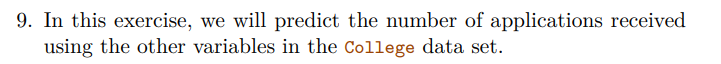

In [ ]:
college = load_data("College")
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [ ]:
college.columns

Index(['Private', 'Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc',
       'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board', 'Books',
       'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend',
       'Grad.Rate'],
      dtype='object')

In [ ]:
college.shape

(777, 18)

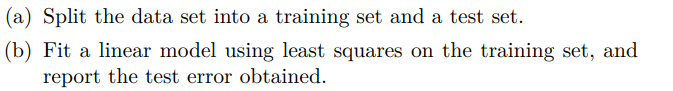

In [ ]:
design = MS(college.columns.drop("Apps")).fit(college)

X = design.transform(college)
y = np.array(college["Apps"])

X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=0.3, random_state=1)

model = OLS(y_train, X_train).fit()

In [ ]:
y_pred = model.predict(X_test)

ols_MSE = np.sum((y_test - y_pred)**2) / y_pred.shape[0]
ols_MSE

642753.897652801

In [ ]:
ols_RMSE = np.sqrt(ols_MSE)
ols_RMSE

801.7193384550487

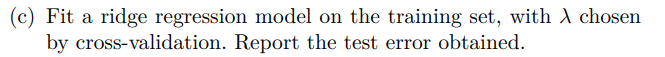

In [ ]:
X_train = X_train.drop('intercept', axis=1)
X_test = X_test.drop('intercept', axis=1)

In [ ]:
K = 5
lambdas = np.linspace(0, 50, 100)

scaler = StandardScaler()
inner_kfold = skm.KFold(n_splits=K,
                        random_state=2,
                        shuffle=True)

ridgeCV = skl.RidgeCV(alphas=lambdas, cv=inner_kfold)
pipeCV = Pipeline(steps=[
  ("scaler", scaler),
  ("ridge", ridgeCV)
])

pipeCV.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge',
                 RidgeCV(alphas=array([ 0.        ,  0.50505051,  1.01010101,  1.51515152,  2.02020202,
        2.52525253,  3.03030303,  3.53535354,  4.04040404,  4.54545455,
        5.05050505,  5.55555556,  6.06060606,  6.56565657,  7.07070707,
        7.57575758,  8.08080808,  8.58585859,  9.09090909,  9.5959596 ,
       10.1010101 , 10.60606061, 11.11111111, 11.61616162, 12.12121212,
       12.62...
       35.35353535, 35.85858586, 36.36363636, 36.86868687, 37.37373737,
       37.87878788, 38.38383838, 38.88888889, 39.39393939, 39.8989899 ,
       40.4040404 , 40.90909091, 41.41414141, 41.91919192, 42.42424242,
       42.92929293, 43.43434343, 43.93939394, 44.44444444, 44.94949495,
       45.45454545, 45.95959596, 46.46464646, 46.96969697, 47.47474747,
       47.97979798, 48.48484848, 48.98989899, 49.49494949, 50.        ]),
                         cv=KFold(n_splits=5, random_state=2, shuffle=True)))])

In [ ]:
tuned_ridge = pipeCV.named_steps["ridge"]
tuned_ridge.alpha_

8.080808080808081

In [ ]:
y_pred = pipeCV.predict(X_test)
ridge_MSE = np.mean((y_test - y_pred)**2)
ridge_RMSE = np.sqrt(np.mean((y_test - y_pred)**2))

print(ridge_MSE)
print(ridge_RMSE)

668492.5378936735
817.6139296108363


In [ ]:
tuned_ridge.coef_

array([-1.63231511e+02,  3.52552333e+03, -2.50526186e+02,  8.51856420e+02,
       -2.44289738e+02,  1.91467139e+02,  3.96478531e+01, -3.03344785e+02,
        2.02248350e+02, -1.17161850e+01, -2.21112834e-01, -1.39384427e+02,
       -4.20845395e+01,  6.40900697e+01, -2.73971161e+01,  4.45765894e+02,
        1.69484877e+02])

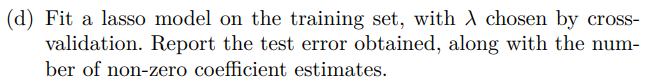

In [ ]:
K = 5
inner_kfold = skm.KFold(n_splits=K,
                        random_state=2,
                        shuffle=True)
scaler = StandardScaler()

lassoCV = skl.ElasticNetCV(l1_ratio=1, cv=inner_kfold)
pipeCV = Pipeline(steps=[
  ("scaler", scaler),
  ("lasso", lassoCV)
])

pipeCV.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 ElasticNetCV(cv=KFold(n_splits=5, random_state=2, shuffle=True),
                              l1_ratio=1))])

In [ ]:
tuned_lasso = pipeCV.named_steps["lasso"]
tuned_lasso.alpha_

35.25263542775875

In [ ]:
tuned_lasso.coef_

array([-9.79298525e+01,  3.54463084e+03, -0.00000000e+00,  5.57558717e+02,
       -0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -2.03090809e+02,
        1.27406960e+02,  0.00000000e+00,  0.00000000e+00, -8.17549143e+01,
       -2.30633926e+01,  0.00000000e+00, -2.47229901e+00,  3.76424922e+02,
        6.88473000e+01])

In [ ]:
y_pred = pipeCV.predict(X_test)
lasso_MSE = np.mean((y_test - y_pred)**2)
lasso_RMSE = np.sqrt(np.mean((y_test - y_pred)**2))

print(lasso_MSE)
print(lasso_RMSE)

711843.8332488547
843.7083816395655


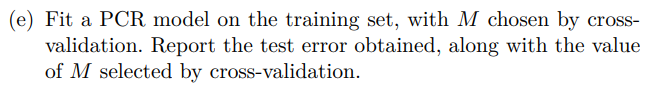

In [ ]:
pca = PCA()
scaler = StandardScaler()
linreg = skl.LinearRegression()

pipe = Pipeline(steps=[
  ("scaler", scaler),
  ("pca", pca),
  ("linreg", linreg)
])

In [ ]:
param_grid = {
  "pca__n_components": range(1, X_train.shape[1] + 1)
}

kfold = skm.KFold(n_splits=K,
                  random_state=2,
                  shuffle=True)

grid = skm.GridSearchCV(
  estimator=pipe,
  cv=kfold,
  param_grid=param_grid,
  scoring="neg_mean_squared_error"
)

grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=2, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('linreg', LinearRegression())]),
             param_grid={'pca__n_components': range(1, 18)},
             scoring='neg_mean_squared_error')

In [ ]:
grid.best_params_

{'pca__n_components': 17}

Text(0.5, 0, '# principal components')

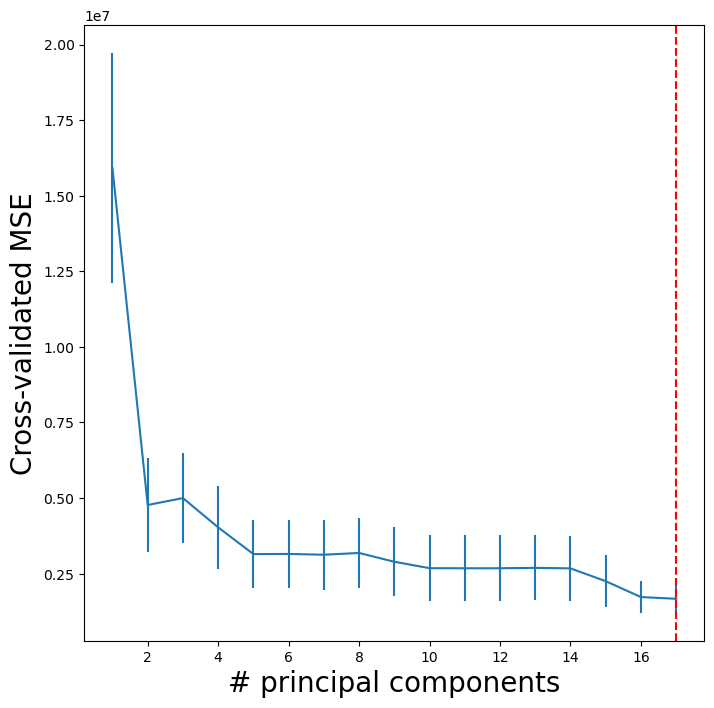

In [ ]:
pca_fig, ax = subplots(figsize=(8, 8))
ax.errorbar(
  range(1, X_train.shape[1] + 1),
  -grid.cv_results_["mean_test_score"],
  grid.cv_results_["std_test_score"] / np.sqrt(K)
)
ax.axvline(grid.best_params_["pca__n_components"], c="r", ls="--")
ax.set_ylabel('Cross-validated MSE', fontsize=20)
ax.set_xlabel('# principal components', fontsize=20)

In [ ]:
pipe.named_steps["pca"].n_components = grid.best_params_["pca__n_components"]
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=17)),
                ('linreg', LinearRegression())])

In [ ]:
y_pred = pipe.predict(X_test)
pca_MSE = np.mean((y_test - y_pred)**2)
pca_RMSE = np.sqrt(np.mean((y_test - y_pred)**2))

print(pca_MSE)
print(pca_RMSE)

642753.8976533805
801.7193384554101


We see that results are the same as in OLS, and it is not strange, because it used all predictors for fitting

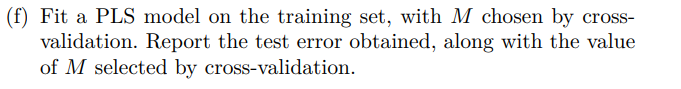

In [ ]:
pls = PLSRegression(scale=True)

param_grid = {'n_components':range(1, 18)}
grid = skm.GridSearchCV(pls,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=2, shuffle=True),
             estimator=PLSRegression(),
             param_grid={'n_components': range(1, 18)},
             scoring='neg_mean_squared_error')

In [ ]:
grid.best_params_

{'n_components': 16}

In [ ]:
pls.n_components = 16
pls.fit(X_train, y_train)

PLSRegression(n_components=16)

In [ ]:
pred = pls.predict(X_test)
pls_MSE = np.mean((pred - y_test)**2)
pls_MSE

642728.9614907267

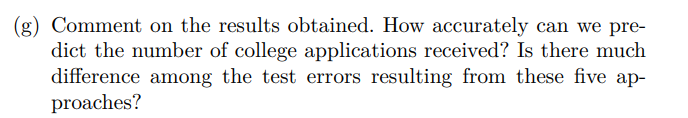

The best fitted model were OLS, PCR and PLS.But, PCR was fitted with all predictors, so it simply was the same as OLS.

Ridge and Lasso showed worse results. So, i can make an assumption that all features are important in this dataset, and shrinking them(line in Ridge) or chossing only the most important(like in Lasso) or do dimension reduction(like in PCA) leads to increasing of test error.

So, simple least sqaures are the best method to use in this dataset

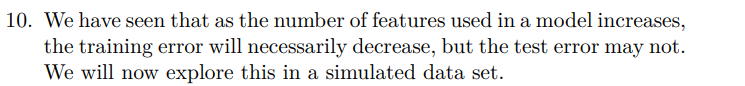

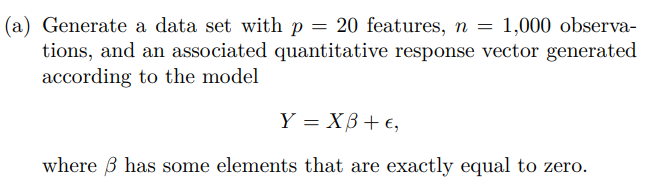

<Axes: >

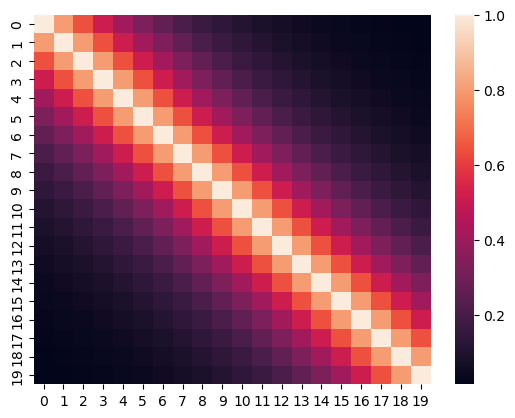

In [3]:
n = 1000
p = 20

def correlation_ar1(p, rho=0.5):
    """
    Returns an AR(1) correlation matrix of dimension p x p 
    with correlation parameter rho.
    AR(1) means Corr(X_i, X_j) = rho^|i - j|.
    """
    Sigma = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            Sigma[i, j] = rho ** abs(i - j)
    return Sigma

Sigma = correlation_ar1(p, rho=0.8)
sns.heatmap(Sigma)

In [4]:
rng = np.random.default_rng(2025)
X = rng.multivariate_normal(mean=np.zeros(p), cov=correlation_ar1(p, rho=0.8), size=n)

eps = rng.normal(0, 7, size=(n, ))
X.shape

(1000, 20)

In [5]:
B = np.array([2, 0, 0, 1, -2,
              -1, 0, 2, 0, 0, 
              0, 0, 0, 0, 0,
              0, 3, 0, 4, 0])

y = np.dot(X, B) + eps
y.shape

(1000,)

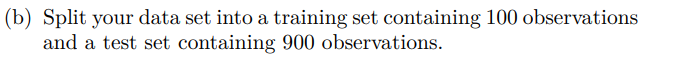

In [7]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=0.9, random_state=42)

In [32]:
from itertools import combinations

def best_subset_selection(X_train, y_train, X_test, y_test):
  p = X_train.shape[1]
  results = pd.DataFrame({
    "subset": pd.Series(dtype=object),
    "train_mse": pd.Series(dtype=float),
    "test_mse": pd.Series(dtype=float)
  })

  for k in range(0, p + 1):
    
    if k == 0:
      linreg = skl.LinearRegression().fit(np.zeros_like(X_train), y_train)
      
      train_y_pred = linreg.predict(X_train)
      train_mse = np.mean((y_train - train_y_pred)**2)
      
      test_y_pred = linreg.predict(X_test)
      test_mse = np.mean((y_test - test_y_pred)**2)
      
      results.loc[k] = [(), train_mse, test_mse]
      
    if k > 0:
      best_model_train_mse = 0
      best_model_test_mse = np.power(10, 10)
      best_model_subset = ()
      
      for subset in combinations(range(p), k):
        linreg = skl.LinearRegression().fit(X_train[:, subset], y_train)
        
        train_y_pred = linreg.predict(X_train[:, subset])
        test_y_pred = linreg.predict(X_test[:, subset])
        
        train_mse = np.mean((y_train - train_y_pred)**2)
        test_mse = np.mean((y_test - test_y_pred)**2)
        
        if test_mse < best_model_test_mse:
          best_model_test_mse = test_mse
          best_model_train_mse = train_mse
          best_model_subset = subset
        
      results.loc[k] = [best_model_subset, best_model_train_mse, best_model_test_mse]
  
  return results

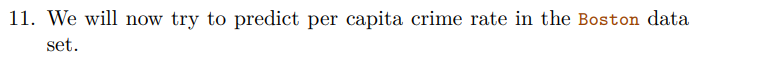

In [35]:
boston = load_data("Boston")
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [37]:
boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [38]:
boston.shape

(506, 13)

In [39]:
X = boston.drop("crim", axis=1)
y = boston["crim"]

In [49]:
def MSE(y_true, y_pred):
  return np.mean((y_true - y_pred)**2)

def RMSE(y_true, y_pred):
  return np.sqrt(MSE(y_true, y_pred))

In [73]:
def visualize(results):
  _, ax = subplots(figsize=(8, 8))
  ax.errorbar(
    results["fold"],
    results["train_MSE"],
    label="Train MSE"
  )
  ax.errorbar(
    results["fold"],
    results["test_MSE"],
    label="Test MSE",
    c="r"
  )
  ax.axhline(results["train_MSE"].mean(), ls="--", label="mean train MSE")
  ax.axhline(results["test_MSE"].mean(), ls="--", c="r", label="mean test MSE")
  ax.legend()

In [ ]:
K = 5
kfold = skm.KFold(n_splits=K, random_state=1, shuffle=True)

def compute_metrics(model, X, y):
  results = pd.DataFrame({
      "fold": pd.Series(dtype=int),
      "train_MSE": pd.Series(dtype=float),
      "train_RMSE": pd.Series(dtype=float),
      "test_MSE": pd.Series(dtype=float),
      "test_RMSE": pd.Series(dtype=float),
  })

  for fold, (train_idx, test_idx) in enumerate(kfold.split(X), start=1):
      X_train = X.iloc[train_idx]
      X_test = X.iloc[test_idx]
      y_train = y.iloc[train_idx]
      y_test = y.iloc[test_idx]
      
      model.fit(X_train, y_train)
      
      results.loc[len(results)] = [
          fold,
          MSE(y_train, model.predict(X_train)),
          RMSE(y_train, model.predict(X_train)),
          MSE(y_test, model.predict(X_test)),
          RMSE(y_test, model.predict(X_test)),
      ]
  
  visualize(results)
  return results
  

least squares

,fold,train_MSE,train_RMSE,test_MSE,test_RMSE
0,1.0,46.889848,6.847616,16.990299,4.121929
1,2.0,34.801767,5.899302,65.285171,8.079924
2,3.0,35.272550,5.939070,63.123247,7.945014
3,4.0,45.420545,6.739477,22.282168,4.720399
4,5.0,40.175046,6.338379,42.920757,6.551394


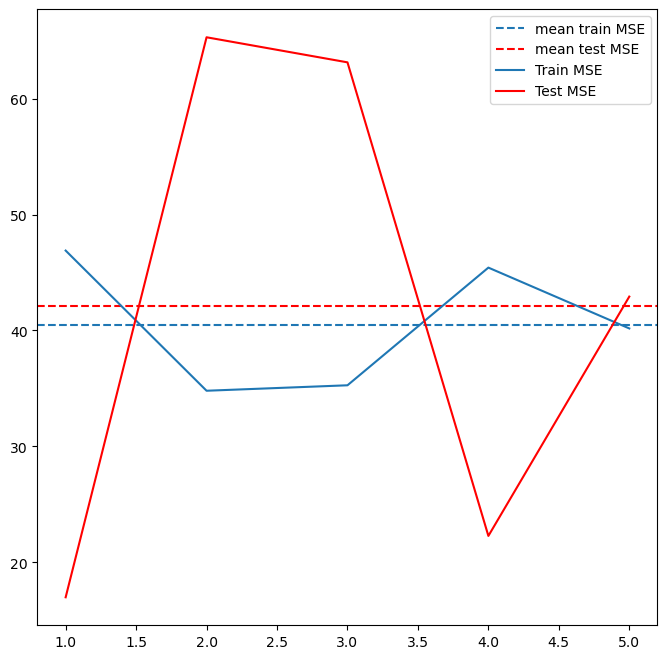

In [76]:
linreg = skl.LinearRegression()

compute_metrics(linreg, X, y)

lasso

,fold,train_MSE,train_RMSE,test_MSE,test_RMSE
0,1.0,47.043624,6.858835,16.089024,4.011113
1,2.0,35.051280,5.920412,65.268380,8.078885
2,3.0,35.280191,5.939713,63.211563,7.950570
3,4.0,45.429317,6.740127,22.188766,4.710495
4,5.0,40.182571,6.338972,42.967665,6.554973


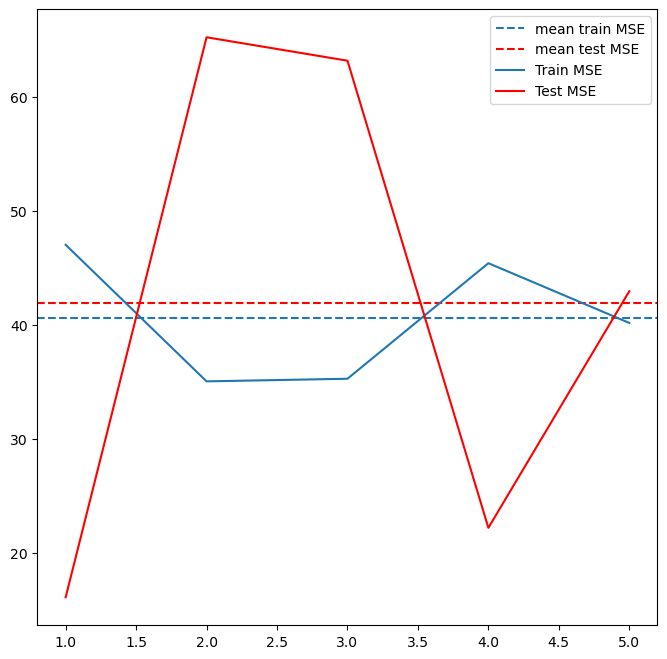

In [77]:
scaler = StandardScaler()
lassoCV = skl.ElasticNetCV(l1_ratio=1, cv=kfold)

pipeCV = Pipeline(steps=[
  ("scaler", scaler),
  ("lasso", lassoCV)
])

compute_metrics(pipeCV, X, y)

In [70]:
tuned_lasso = pipeCV.named_steps["lasso"]

tuned_lasso.alpha_

np.float64(0.010676932929930485)

In [71]:
tuned_lasso.coef_

array([ 0.98208073, -0.33250659, -0.18683145, -1.05167381,  0.61364233,
       -0.01545979, -2.02816413,  4.9872109 , -0.36953038, -0.54120438,
        0.86360917, -1.98094904])

ridge

,fold,train_MSE,train_RMSE,test_MSE,test_RMSE
0,1.0,47.989691,6.927459,15.275896,3.908439
1,2.0,35.472424,5.955873,65.930670,8.119770
2,3.0,36.180185,6.014997,65.276924,8.079414
3,4.0,46.201724,6.797185,21.974738,4.687722
4,5.0,40.259087,6.345005,43.209708,6.573409


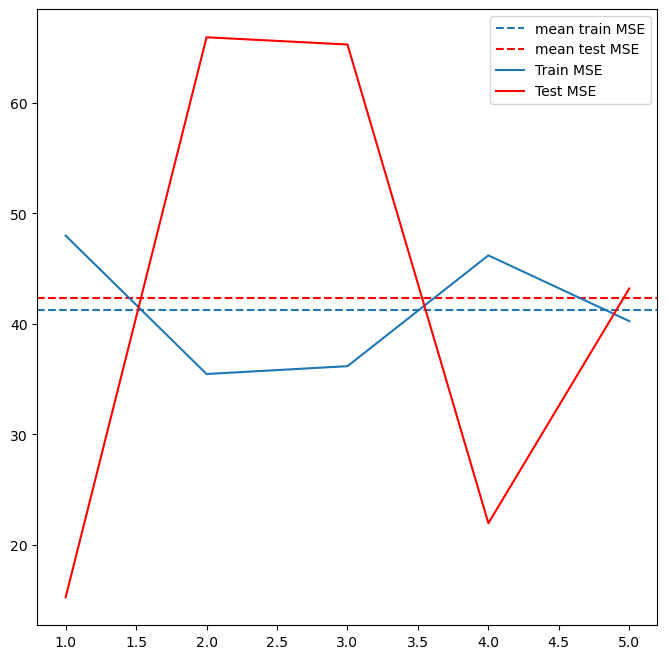

In [79]:
lambdas = np.linspace(0, 100, 100)

ridgeCV = skl.RidgeCV(alphas=lambdas, cv=kfold)
pipeCV = Pipeline(steps=[
  ("scaler", scaler),
  ("ridge", ridgeCV)
])

compute_metrics(pipeCV, X, y)

In [81]:
tuned_ridge = pipeCV.named_steps["ridge"]
tuned_ridge.alpha_

np.float64(8.080808080808081)

In [82]:
tuned_ridge.coef_

array([ 0.9028691 , -0.40356399, -0.19333158, -0.87330766,  0.61111883,
       -0.04683862, -1.87855875,  4.45722851,  0.09068771, -0.45006086,
        0.95889865, -1.80804177])

So, we see, that all models shows approxmately the same training and test error.  